# **Analyse du papier de recherche Center-Based 3D Object Detection and Tracking** 

*Auteur :* Erwan Ouabdesselam

# **Introduction**

## **Contexte : perception 3D pour la conduite autonome**

La détection d’objets en 3D constitue un élément fondamental des systèmes de conduite autonome.  
Contrairement à la détection 2D basée sur les images, la perception 3D repose souvent sur des nuages de points LiDAR, qui sont naturellement clairsemés et géométriquement irréguliers.

Plusieurs difficultés spécifiques apparaissent dans ce contexte :

- la majorité de l’espace observé ne contient aucune mesure ;
- les objets peuvent apparaître avec des orientations arbitraires dans le plan ;
- les différentes classes d’objets présentent des tailles et des formes très hétérogènes.

Ces caractéristiques rendent la détection d’objets en 3D sensiblement plus complexe que dans le cadre de la détection 2D classique.

---

## **Limites des détecteurs 3D *anchor-based***

De nombreuses méthodes de détection d’objets reposent sur le principe des *anchors*.  
Cette approche consiste à définir un ensemble de boîtes candidates prédéfinies, disposées sur une grille spatiale.  
Chaque ancre représente une hypothèse initiale sur la position et la taille d’un objet potentiel.

Lors de l’apprentissage, le réseau prédit pour chaque ancre :

- une probabilité de présence d’objet ;
- des corrections géométriques permettant d’ajuster la boîte prédéfinie afin de mieux correspondre à l’objet réel.

Cette stratégie s’est révélée particulièrement efficace pour la détection d’objets dans les images, où les boîtes sont généralement alignées avec les axes de l’image.

Cependant, son extension à la détection 3D est plus délicate.  
Les objets dans un nuage de points peuvent apparaître avec une grande variété d’orientations et de dimensions.  
Afin de couvrir cet espace de configurations, il devient nécessaire d’introduire un grand nombre d’ancres correspondant à différentes tailles et orientations possibles.

Cette multiplication des ancres entraîne plusieurs inconvénients :

- une augmentation du coût computationnel ;
- une assignation plus complexe des exemples positifs et négatifs pendant l’entraînement ;
- un risque accru de faux positifs dû au grand nombre d’hypothèses générées.

Ces limitations suggèrent que la difficulté du problème ne réside pas uniquement dans l’extraction de caractéristiques à partir du nuage de points, mais également dans la représentation choisie pour modéliser les objets détectés.  
Elles motivent ainsi l’exploration d’approches alternatives ne reposant pas sur des ancres prédéfinies.

---

## **Idée principale de l’approche center-based**

CenterPoint reformule le problème de détection : au lieu de prédire directement des boîtes 3D ancrées, le modèle détecte d’abord les *centres* d’objets en vue BEV (Bird’s Eye View), puis régresse leurs attributs géométriques.

Concrètement, le nuage de points LiDAR est d’abord encodé par un backbone 3D (par exemple VoxelNet ou PointPillars) afin de produire une représentation spatiale en vue BEV.  
Sur cette représentation, la détection est formulée comme un problème d’estimation de points clés, inspiré des approches center-based utilisées en détection 2D telles que CenterNet.

L’intuition est simple : une boîte 3D possède une orientation intrinsèque, alors qu’un point n’en possède pas. En détectant directement les centres des objets, le modèle évite d’énumérer explicitement un grand nombre d’hypothèses d’orientation.

Le pipeline suit alors deux étapes principales :

1. prédiction d’une heatmap de centres d’objets en vue BEV ;
2. régression, au centre détecté, des attributs géométriques : dimensions de la boîte, orientation (yaw), position verticale et vitesse.

Cette formulation réduit l’espace de recherche du détecteur, simplifie l’apprentissage et facilite naturellement l’intégration du suivi temporel des objets.

---

## **Contributions de CenterPoint**

Les contributions majeures de l’approche peuvent être résumées ainsi :

- une formulation *center-based* de la détection 3D qui supprime la dépendance aux ancres et réduit l’espace de recherche du détecteur ;
- une prédiction conjointe de la détection et du suivi d’objets grâce à l’estimation de la vitesse ;
- un module de raffinement léger en seconde étape permettant d’améliorer la précision des boîtes prédites ;
- une architecture simple et modulaire, compatible avec différents backbones LiDAR ;
- des performances de référence sur les benchmarks nuScenes et Waymo en détection 3D et en suivi multi-objets.



# **Dataset Exploration**


In order to illustrate the different components of the CenterPoint pipeline, we use examples from the **nuScenes dataset**.

nuScenes is a large-scale autonomous driving dataset designed for 3D perception tasks. It contains data collected from a vehicle equipped with multiple sensors:

- 1 LiDAR sensor
- 6 cameras
- 5 radars

Although several sensors are available, **CenterPoint operates only on LiDAR point clouds**. The LiDAR sensor provides a 3D representation of the environment in the form of point clouds.

In this section we briefly explore the structure of the dataset and visualize a sample LiDAR frame that will be used throughout the notebook to illustrate the different processing stages of the CenterPoint pipeline.

### LiDAR representation

LiDAR sensors measure the distance between the sensor and surrounding objects by emitting laser pulses and measuring the time of flight of the reflected signal.

The result is a **point cloud**, which is a set of 3D points describing the geometry of the environment.

Each point contains several attributes:

- \(x, y, z\): spatial coordinates
- intensity: reflectance value returned by the LiDAR sensor

Unlike images, point clouds are **sparse and irregular**, which makes them difficult to process with standard convolutional neural networks.

### Coordinate system

The LiDAR point clouds are expressed in the **ego vehicle coordinate system**.

- x axis: forward direction of the vehicle
- y axis: lateral direction
- z axis: vertical axis

The origin corresponds to the position of the LiDAR sensor mounted on the vehicle.

This coordinate system is important for interpreting the spatial structure of the scene and for predicting the 3D bounding boxes of objects.

### Object annotations

The nuScenes dataset provides **3D bounding box annotations** for objects present in each scene.

Each annotation contains:

- the 3D position of the object center
- the object dimensions (length, width, height)
- the orientation (yaw angle)
- the object category

These annotations are used as supervision signals during training of 3D object detection models such as CenterPoint.

### Challenges of LiDAR data

Although LiDAR provides accurate 3D measurements, point clouds present several challenges for deep learning models:

- The data is **sparse** compared to images.
- Points are **irregularly distributed** in space.
- The spatial range of the scene can extend over tens of meters.

To address these challenges, CenterPoint converts the raw point cloud into a structured representation before applying convolutional neural networks.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from nuscenes.utils.data_classes import LidarPointCloud

In [2]:
from nuscenes.nuscenes import NuScenes

DATAROOT = "data/nuScenes"


nusc = NuScenes(
    version='v1.0-mini',
    dataroot=DATAROOT,
    verbose=True
)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.7 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


### **nuScenes structure**

The nuScenes dataset is organized as a relational database composed of several tables. The most important elements are:

- **scene**: a short driving sequence
- **sample**: a timestamp within a scene
- **sample_data**: sensor data associated with a sample
- **sample_annotation**: 3D bounding box annotations

The structure of the dataset can be summarized as:

scene → sample → sample_data → sensor files (à vérif)

For the purpose of this project, we focus on the **LiDAR sensor**, which provides the 3D point clouds used by CenterPoint.

### **Accessing a LiDAR frame**

Each scene contains multiple samples corresponding to key timestamps.  
For each sample, several sensors are recorded, including the LiDAR sensor.

We extract a LiDAR frame from the first scene to visualize the raw point cloud.

In [17]:
scene = nusc.scene[0]

first_sample_token = scene["first_sample_token"]
sample = nusc.get("sample", first_sample_token)

lidar_token = sample["data"]["LIDAR_TOP"]
lidar_data = nusc.get("sample_data", lidar_token)


lidar_path = os.path.join(DATAROOT, lidar_data["filename"])

pc = LidarPointCloud.from_file(lidar_path)
points = pc.points

print("Point cloud shape:", points.shape)

Point cloud shape: (4, 34688)


### **LiDAR point cloud representation**

A LiDAR frame is represented as a set of 3D points.  
Each point contains several attributes:

- **x, y, z**: spatial coordinates
- **intensity**: reflectance returned by the LiDAR sensor

These point clouds provide a sparse 3D representation of the environment and constitute the primary input of the CenterPoint detection pipeline.

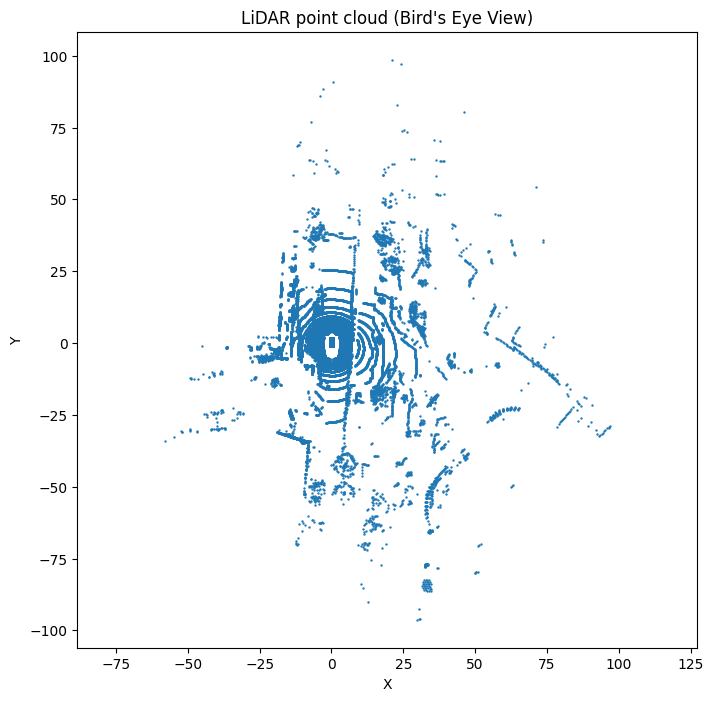

In [18]:
x = points[0, :]
y = points[1, :]

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.5)

plt.title("LiDAR point cloud (Bird's Eye View)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")

plt.show()

The raw point cloud shown above corresponds to the input representation used by CenterPoint.

However, directly processing raw point clouds with deep neural networks is computationally expensive.  
Therefore, CenterPoint first converts the point cloud into a structured representation before applying convolutional networks.

In the following sections, we will study how this transformation is performed within the CenterPoint pipeline.

In [19]:
import imageio
from tqdm import tqdm

frames = []

scene = nusc.scene[0]
sample_token = scene["first_sample_token"]

for i in tqdm(range(30)):  # ~3 secondes
    sample = nusc.get("sample", sample_token)

    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    lidar_path = os.path.join(DATAROOT, lidar_data["filename"])
    pc = LidarPointCloud.from_file(lidar_path)

    points = pc.points

    x = points[0, :]
    y = points[1, :]

    fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(x, y, s=0.5)

    ax.set_xlim(-50,50)
    ax.set_ylim(-50,50)

    ax.set_title("LiDAR BEV")
    ax.set_aspect("equal")

    fig.canvas.draw()

    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    
    frames.append(frame)

    plt.close()

    if sample["next"] == "":
        break

    sample_token = sample["next"]

# Save GIF
imageio.mimsave("lidar_sequence.gif", frames, fps=10)

100%|██████████| 30/30 [00:03<00:00,  9.45it/s]


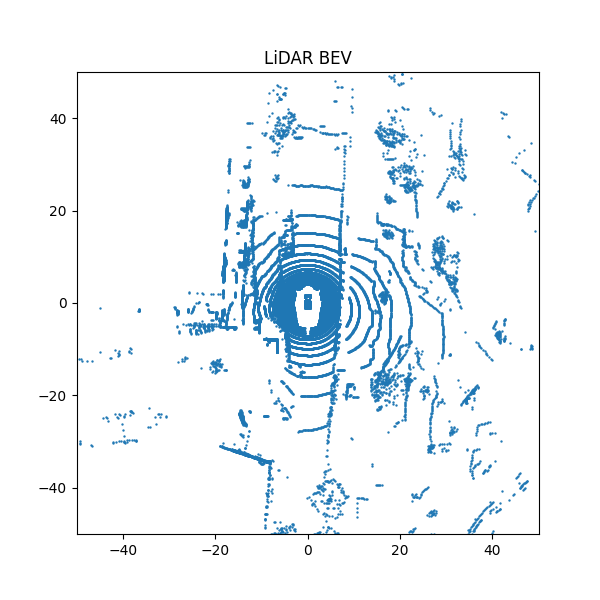

In [1]:
from IPython.display import Image
Image("lidar_sequence.gif")